# SmartCart: Part 3: Association Rule Mining (Apriori)

##  Imports

In [2]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "mlxtend", "-q"])

# ── Part 3 Imports ───────────────────────────────────────────────────────
# mlxtend : machine-learning extensions library that provides:
#   TransactionEncoder        → converts list-of-lists to a boolean matrix
#   apriori                   → finds frequent itemsets
#   association_rules         → derives if-then rules from frequent itemsets
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option('display.max_columns', None)
np.random.seed(42)



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip


## 3.1  Load Data & Convert User Interactions into Transactions

In [3]:
# ── Load Data & Build Transaction Baskets ─────────────────────────────────
# Association rule mining works on TRANSACTIONS, not a rating matrix.
# Each transaction = one user's complete set of interacted products.
import pandas as pd
import numpy as np

# Load raw data
user_data = pd.read_csv('ecommerce_user_data.csv')
product_data = pd.read_csv('product_details.csv')

# Basic cleaning: parse dates and remove duplicate (user, product) pairs
user_data['Timestamp'] = pd.to_datetime(user_data['Timestamp'])
user_data = user_data.drop_duplicates(['UserID', 'ProductID'], keep='last')

# Group by user: each user becomes one 'basket' containing all their product IDs.
# set(x) removes any accidental duplicates within a single user's basket.
transactions = (
    user_data.groupby('UserID')['ProductID']
    .apply(lambda x: list(set(x)))
    .tolist()
)

# Quick stats to understand basket characteristics
basket_sizes = [len(t) for t in transactions]

print("Users:", user_data['UserID'].nunique())
print("Products:", user_data['ProductID'].nunique())
print("Transactions:", len(transactions))
print("Avg basket size:", np.mean(basket_sizes))
print("Min/Max basket size:", min(basket_sizes), "/", max(basket_sizes))

print("\nExample basket:")
print(transactions[0])


Users: 50
Products: 100
Transactions: 50
Avg basket size: 14.48
Min/Max basket size: 10 / 20

Example basket:
['P0021', 'P0012', 'P0048', 'P0071', 'P0070', 'P0050', 'P0013', 'P0047', 'P0005', 'P0044', 'P0014', 'P0079', 'P0007', 'P0042', 'P0020', 'P0003', 'P0009', 'P0033', 'P0046', 'P0028']


## 3.2  One-Hot Encode the Transaction Baskets


In [4]:
# ── One-Hot Encode the Transaction Baskets ────────────────────────────────
# TransactionEncoder converts the list-of-lists format into a boolean matrix:
#   Rows    = transactions (one per user)
#   Columns = all unique product IDs
#   Values  = True if the product is in that user's basket, False otherwise
# This boolean matrix is the required input format for mlxtend's apriori.
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)  # fit learns all unique items

transaction_df = pd.DataFrame(te_array, columns=te.columns_)

print("Transaction matrix shape:", transaction_df.shape)
transaction_df.head()


Transaction matrix shape: (50, 100)


,P0000,P0001,P0002,P0003,P0004,P0005,P0006,P0007,P0008,P0009,P0010,P0011,P0012,P0013,P0014,P0015,P0016,P0017,P0018,P0019,P0020,P0021,P0022,P0023,P0024,P0025,P0026,P0027,P0028,P0029,P0030,P0031,P0032,P0033,P0034,P0035,P0036,P0037,P0038,P0039,P0040,P0041,P0042,P0043,P0044,P0045,P0046,P0047,P0048,P0049,P0050,P0051,P0052,P0053,P0054,P0055,P0056,P0057,P0058,P0059,P0060,P0061,P0062,P0063,P0064,P0065,P0066,P0067,P0068,P0069,P0070,P0071,P0072,P0073,P0074,P0075,P0076,P0077,P0078,P0079,P0080,P0081,P0082,P0083,P0084,P0085,P0086,P0087,P0088,P0089,P0090,P0091,P0092,P0093,P0094,P0095,P0096,P0097,P0098,P0099
0,False,False,False,True,False,True,False,True,False,True,False,False,True,True,True,False,False,False,False,False,True,True,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,True,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,True,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,False,False,False,False,False,False,True,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False
4,False,True,False,False,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True,False,False,False,False,False,True,True


## 3.3  Frequent Itemsets


In [5]:
# ── Find Frequent Itemsets with Apriori ──────────────────────────────────
# Support of an itemset = fraction of transactions that contain it.
# min_support = 0.10 means a product (or product combination) must appear
# in at least 10% of user baskets (≥ 5 out of 50 users) to be considered frequent.
# Too low → too many trivial itemsets; too high → too few results.
min_support = 0.10

frequent_itemsets = apriori(
    transaction_df,
    min_support=min_support,
    use_colnames=True   # keep product ID labels instead of column indices
)

# Add a column for itemset size (1 = single product, 2 = pair, etc.)
frequent_itemsets['itemset_length'] = frequent_itemsets['itemsets'].apply(len)

# Sort by support descending so the most common itemsets appear first
frequent_itemsets = frequent_itemsets.sort_values(
    by=['support', 'itemset_length'],
    ascending=[False, False]
).reset_index(drop=True)

print(f"Frequent itemsets found: {len(frequent_itemsets)}")
print("\nItemsets by size:")
print(frequent_itemsets['itemset_length'].value_counts().sort_index())

frequent_itemsets.head(10)


Frequent itemsets found: 109

Itemsets by size:
itemset_length
1    91
2    18
Name: count, dtype: int64


,support,itemsets,itemset_length
0,0.34,(P0070),1
1,0.26,(P0051),1
2,0.26,(P0089),1
3,0.24,(P0043),1
4,0.24,(P0088),1
5,0.22,(P0004),1
6,0.22,(P0030),1
7,0.22,(P0044),1
8,0.22,(P0065),1
9,0.22,(P0077),1


## 3.4  Association Rules


Interpretation:
- higher confidence means the consequent often appears when the antecedent appears
- lift > 1 suggests a positive association stronger than random chance

In [6]:
# ── Generate Association Rules ────────────────────────────────────────────
# An association rule has the form:  antecedent → consequent
# Key metrics:
#   Support    : P(A ∩ B)        — how often both appear together
#   Confidence : P(B | A)        — given A is bought, how often B is too
#   Lift       : conf / P(B)     — how much more likely B is given A vs. random
#                lift > 1 → positive association (better than chance)
#
# We filter by min_confidence = 0.50, meaning the rule must be correct
# at least 50% of the time.
min_confidence = 0.50

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=min_confidence
)

# Keep only the most useful columns
rules = rules[[
    'antecedents', 'consequents',
    'support', 'confidence', 'lift'
]].copy()

# Sort by lift first — highest lift = strongest non-random association
rules = rules.sort_values(
    by=['lift', 'confidence', 'support'],
    ascending=False
).reset_index(drop=True)

print(f"Association rules found: {len(rules)}")
rules.head(10)


Association rules found: 19


,antecedents,consequents,support,confidence,lift
0,(P0039),(P0015),0.1,0.714286,4.464286
1,(P0015),(P0039),0.1,0.625000,4.464286
2,(P0013),(P0079),0.1,0.714286,3.571429
3,(P0079),(P0013),0.1,0.500000,3.571429
4,(P0076),(P0065),0.1,0.714286,3.246753
5,(P0042),(P0070),0.1,1.000000,2.941176
6,(P0011),(P0004),0.1,0.555556,2.525253
7,(P0011),(P0077),0.1,0.555556,2.525253
8,(P0064),(P0079),0.1,0.500000,2.500000
9,(P0079),(P0064),0.1,0.500000,2.500000


## 3.5  Making the Results Human-Readable

In [7]:
# ── Make Results Human-Readable ──────────────────────────────────────────
# The rules currently show product IDs (e.g. P0039 → P0015).
# We map these to real product names for easier interpretation.
product_lookup = product_data.set_index('ProductID')[['ProductName', 'Category']]


def itemset_to_product_names(itemset):
    """Convert a frozenset of ProductIDs into a comma-separated string of names."""
    return ", ".join(
        product_lookup.loc[pid, 'ProductName'] if pid in product_lookup.index else pid
        for pid in sorted(itemset)   # sort for consistent display order
    )


# Add readable names to the frequent itemsets table
frequent_itemsets['itemset_names'] = frequent_itemsets['itemsets'].apply(itemset_to_product_names)

# Add readable names and a formatted rule string to the rules table
rules['antecedents_names'] = rules['antecedents'].apply(itemset_to_product_names)
rules['consequents_names'] = rules['consequents'].apply(itemset_to_product_names)
rules['rule'] = rules['antecedents_names'] + '  →  ' + rules['consequents_names']

print("Top frequent itemsets:")
display(
    frequent_itemsets[['support', 'itemset_length', 'itemset_names']].head(10)
)

print("Top association rules:")
display(
    rules[['rule', 'support', 'confidence', 'lift']].head(10)
)


Top frequent itemsets:


,support,itemset_length,itemset_names
0,0.34,1,Beauty Item 70
1,0.26,1,Home Item 51
2,0.26,1,Clothing Item 89
3,0.24,1,Books Item 43
4,0.24,1,Clothing Item 88
5,0.22,1,Clothing Item 4
6,0.22,1,Books Item 30
7,0.22,1,Clothing Item 44
8,0.22,1,Toys Item 65
9,0.22,1,Home Item 77


Top association rules:


,rule,support,confidence,lift
0,Toys Item 39 → Toys Item 15,0.1,0.714286,4.464286
1,Toys Item 15 → Toys Item 39,0.1,0.625000,4.464286
2,Clothing Item 13 → Home Item 79,0.1,0.714286,3.571429
3,Home Item 79 → Clothing Item 13,0.1,0.500000,3.571429
4,Home Item 76 → Toys Item 65,0.1,0.714286,3.246753
5,Clothing Item 42 → Beauty Item 70,0.1,1.000000,2.941176
6,Books Item 11 → Clothing Item 4,0.1,0.555556,2.525253
7,Books Item 11 → Home Item 77,0.1,0.555556,2.525253
8,Electronics Item 64 → Home Item 79,0.1,0.500000,2.500000
9,Home Item 79 → Electronics Item 64,0.1,0.500000,2.500000


## 3.6  Visualisations

### (a) Top Frequent Itemsets by Support

Saved: part3_frequent_itemsets.csv
Saved: part3_association_rules.csv


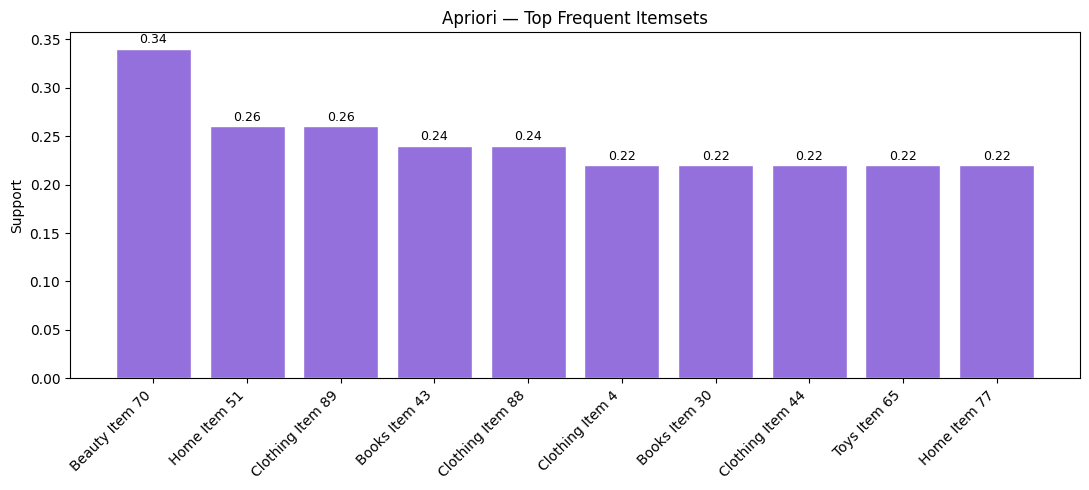

In [8]:
# ── Save Results & Plot Top Frequent Itemsets ────────────────────────────
# Export the itemsets and rules to CSV for reporting
frequent_itemsets[['support', 'itemset_length', 'itemset_names']].to_csv(
    'part3_frequent_itemsets.csv', index=False
)
rules[['rule', 'support', 'confidence', 'lift']].to_csv(
    'part3_association_rules.csv', index=False
)
print("Saved: part3_frequent_itemsets.csv")
print("Saved: part3_association_rules.csv")

# Bar chart of the 10 most frequent itemsets
top_itemsets = frequent_itemsets.head(10).copy()

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(top_itemsets['itemset_names'], top_itemsets['support'],
       color='mediumpurple', edgecolor='white')

ax.set_ylabel('Support')
ax.set_title('Apriori — Top Frequent Itemsets')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its exact support value
for i, val in enumerate(top_itemsets['support']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_itemsets.png', dpi=150)
plt.show()


### (b) Top Association Rules by Lift

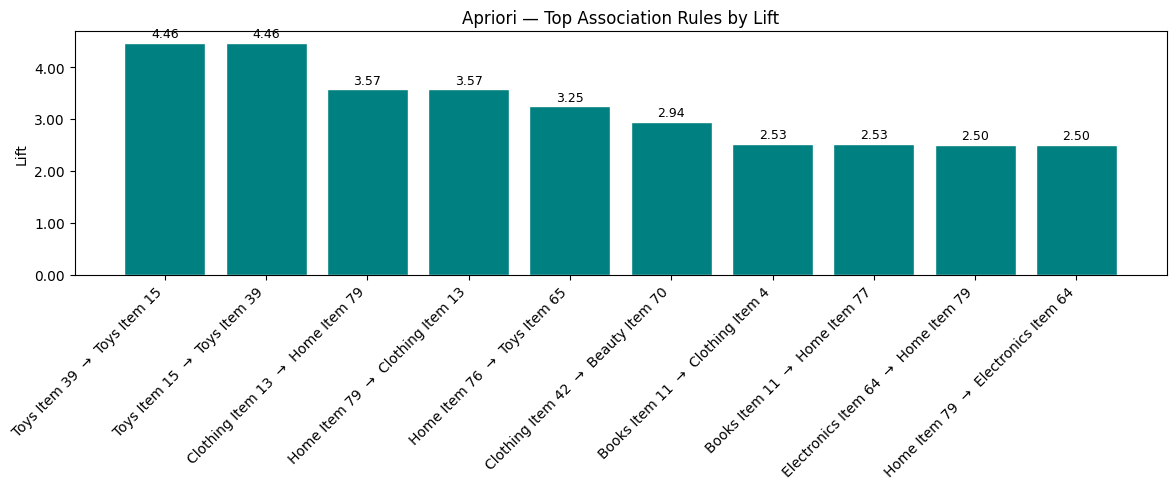

In [9]:
# ── Plot Top Association Rules by Lift ───────────────────────────────────
# Lift is the best metric for ranking rules:
#   lift = 1  → products appear together purely by chance
#   lift > 1  → products appear together MORE often than expected → genuine pattern
top_rules = rules.head(10).copy()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(top_rules['rule'], top_rules['lift'],
       color='teal', edgecolor='white')

ax.set_ylabel('Lift')
ax.set_title('Apriori — Top Association Rules by Lift')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.xticks(rotation=45, ha='right')

# Annotate each bar with its lift value
for i, val in enumerate(top_rules['lift']):
    ax.annotate(f'{val:.2f}',
                xy=(i, val),
                xytext=(0, 4),
                textcoords='offset points',
                ha='center',
                fontsize=9)

plt.tight_layout()
plt.savefig('part3_top_rules_by_lift.png', dpi=150)
plt.show()


### (c) Part 3 Summary Table

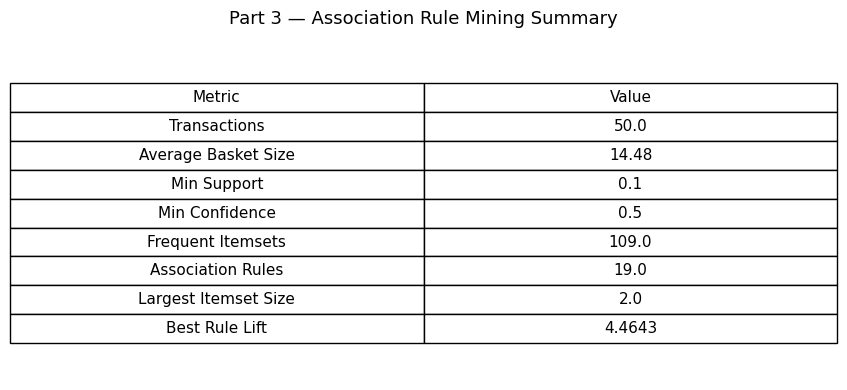

              Metric    Value
        Transactions  50.0000
 Average Basket Size  14.4800
         Min Support   0.1000
      Min Confidence   0.5000
   Frequent Itemsets 109.0000
   Association Rules  19.0000
Largest Itemset Size   2.0000
      Best Rule Lift   4.4643


In [10]:
# ── Part 3 Summary Table ──────────────────────────────────────────────────
# Collect all key parameters and results into one overview table.
summary = pd.DataFrame({
    'Metric': [
        'Transactions',           # total number of user baskets
        'Average Basket Size',    # avg products per user
        'Min Support',            # threshold used for apriori
        'Min Confidence',         # threshold used for rule generation
        'Frequent Itemsets',      # itemsets that passed the support threshold
        'Association Rules',      # rules that passed the confidence threshold
        'Largest Itemset Size',   # max number of products in one itemset
        'Best Rule Lift'          # highest lift among all generated rules
    ],
    'Value': [
        len(transactions),
        round(np.mean(basket_sizes), 2),
        min_support,
        min_confidence,
        len(frequent_itemsets),
        len(rules),
        frequent_itemsets['itemset_length'].max(),
        round(rules['lift'].max(), 4) if len(rules) else np.nan
    ]
})

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')   # hide axes — table only
tbl = ax.table(
    cellText=summary.values,
    colLabels=summary.columns,
    cellLoc='center',
    loc='center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.4, 1.6)

plt.title('Part 3 — Association Rule Mining Summary', fontsize=13, pad=16)
plt.tight_layout()
plt.savefig('part3_summary_table.png', dpi=150)
plt.show()

print(summary.to_string(index=False))


### Key Observations
- The data was converted into 50 user-level transaction baskets, with an average basket size of about 14.48 products.

- Using a minimum support of 0.10 kept the results simple while still capturing useful co-occurrence patterns.

- Most frequent itemsets were single items or pairs, which makes sense since larger combinations happen less often.

- The strongest rules had lift values greater than 1, meaning those product combinations appear together more often than random chance.

- Since this dataset reflects user interactions (not actual purchases), these rules should be seen as patterns of shared interest and not 
guaranteed product bundles.